In [24]:
import random
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
numProcs = random.randint(10, 20)

with open("procList.txt", "w") as f:
    for i in range(numProcs):
        rng0 = random.randint(0,1)
        rng1 = random.randint(0,1)
        rng2 = random.randint(0,1)
        proc = f"{i+1}"
        if (rng0 == 0):
            proc += f" {random.randint(1,25)}"
            proc += f" {random.randint(1,25)}"
        if (rng1 == 0):
            proc += f" {random.randint(1,25)}"
        if (rng2 == 0):
            proc += f" {random.randint(1,25)}"
            proc += f" {random.randint(1,25)}"
        if (rng0 == 1):
            proc += f" {random.randint(1,25)}"
        if (rng2 == 1):
            proc += f" {random.randint(1,25)}"
        if (i+1 < numProcs):
            f.write(f"{proc}\n")
        else:
            f.write(f"{proc}")

In [26]:
with open("procList_output.txt", "w") as f:
    subprocess.run(["a.exe"], stdout=f)

Total Distribution:
status   b    d   p    r
procID                  
1       18  129  23   95
2        0  237   3   24
3       32  109  23   99
4        0  224   7   31
5       39  103  24   95
6       35   90  17  118
7       25   81  15  138
8       24   67  14  153
9        0  163  20   74
10       8   49  19  180
11      18    1  18  218
12      38   33  11  172
13      35    9  23  186

b: Blocked | d: Done | n: No Action | p: Running | r: Ready



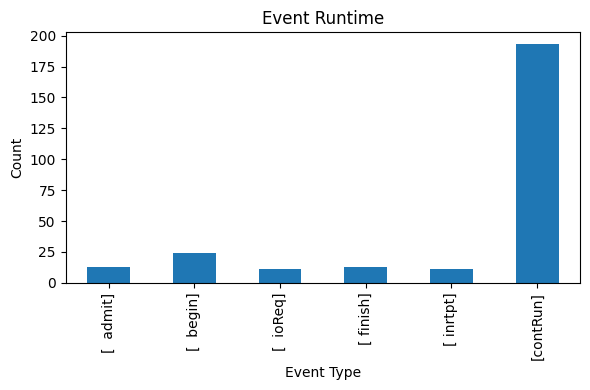

<Figure size 1000x500 with 0 Axes>

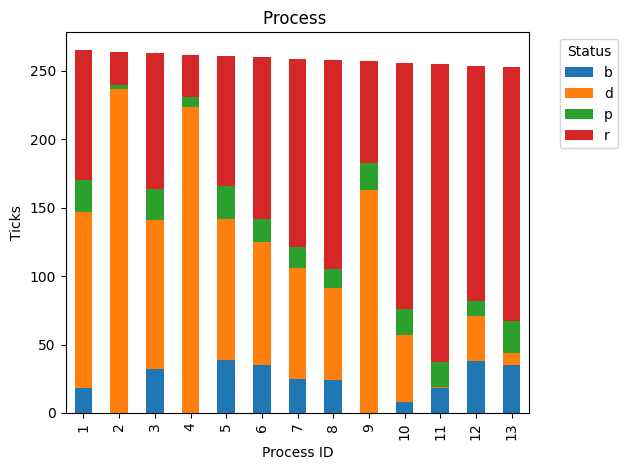

In [31]:
df = pd.read_csv(
    "procList_output.txt",
    sep="\t",
    header=None,
    names=["tick","state","total"]
)

df["state"].str.extract(r"\[\s*(\w+)\s*\]")[0]
df.replace("contRun", "Running")
df.replace("ioReq", "Blocked")
df.replace("inrtpt", "Interrupted")
df.replace("begin", "Begin")
df.replace("finish", "Finished")
df.replace("admit", "Admitted")

records = []
for row_index in range(len(df)):
    total_string = df.loc[row_index, "total"]
    trimmed = total_string.strip()
    tokens = trimmed.split()
    for i in range(len(tokens)):
        proc_id = i + 1
        status_code = tokens[i]
        record = {
            "procID": proc_id,
            "status": status_code
        }
        records.append(record)
tl_df = pd.DataFrame(records)

#total chart
per_proc = (
    tl_df
      .groupby(["procID","status"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
print("Total Distribution:")
print(per_proc)
print("\nb: Blocked | d: Done | n: No Action | p: Running | r: Ready\n")

#total bar graph
state_counts = df["state"].value_counts().sort_index()
plt.figure(figsize=(6,4))
state_counts.plot.bar()
plt.title("Event Runtime")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#proc graph
plt.figure(figsize=(10,5))
per_proc.plot.bar(stacked=True, legend=True)
plt.title("Process ")
plt.xlabel("Process ID")
plt.ylabel("Ticks")
plt.legend(title="Status", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()
